In [13]:
import dipy
import os
import subprocess
import nibabel as nib
import numpy as np
from dipy.core.gradients import gradient_table
from dipy.io.image import load_nifti, save_nifti
from dipy.reconst.dti import TensorModel
from dipy.align.imaffine import AffineMap, MutualInformationMetric, AffineRegistration
from dipy.align.transforms import TranslationTransform3D, RigidTransform3D
import os
import sys
sys.path.append('../../')
from cardpy.Sample_Data.Data_Paths                  import *
from cardpy.Data_Sorting                            import *
from cardpy.Data_Saving                             import *
from cardpy.Data_Processing.Gibbs                   import *
from cardpy.Data_Processing.Registration            import *
from cardpy.Data_Processing.Rejection               import *
from cardpy.Data_Processing.Respiratory             import *
from cardpy.Data_Processing.Diffusivity             import *
from cardpy.Data_Processing.Averaging               import *
from cardpy.Data_Processing.Denoising               import *
from cardpy.Data_Processing.Interpolation           import *
from cardpy.Data_Processing.Segmentation_Matrix_DTI import *
from cardpy.Sample_Data.Data_Paths import *
from cardpy.Data_Import            import *
from cardpy.Data_Sorting           import *
from cardpy.Data_Processing.DTI    import *
from cardpy.Data_Processing.DWI    import *
from cardpy.GUI_Tools              import IntERCOMS
from cardpy.Colormaps              import *
from cardpy.Data_Saving            import *
from cardpy.Data_Processing.cDTI   import *
from cardpy.GUI_Tools                     import *
from cardpy.Colormaps                     import *
# import cardpy
from cardpy.Data_Processing.DTI    import *
from cardpy.GUI_Tools              import IntERCOMS
from cardpy.Colormaps              import *
from matplotlib import pyplot as plt
import os
import subprocess
import nibabel as nib
import numpy as np
import glob
from scipy.io import savemat

import numpy as np
import h5py
from   cardpy.FT_Operators import fft2c, ifft2c 
from cardpy.Data_Import import NifTi_Reader
from matplotlib import pyplot as plt     
from cardpy.Data_Import            import *
from cardpy.Data_Sorting           import *

from dipy.core.histeq import histeq
from dipy.data import get_fnames
from dipy.segment.mask import median_otsu
import os
import nrrd

#smb://171.65.44.79/RSLVA-RAID

In [14]:
import subprocess
import os
import numpy as np

def normalize_complex_image(img_complex, target_value=1000, percentile=95):
    """
    Normalize a complex MRI image using the given percentile of the magnitude,
    then reconstruct the complex image as magnitude * exp(1j * phase).

    Parameters:
        img_complex : np.ndarray
            Coil-combined complex image
        target_value : float
            Desired value for the chosen percentile after scaling
        percentile : float
            Percentile of the magnitude to use for scaling (0-100)

    Returns:
        img_complex_scaled : np.ndarray
            Complex image scaled, phase preserved
        img_mag_scaled : np.ndarray
            Magnitude image ready for DICOM/export
        rescale_slope : float
            Applied scaling factor
    """
    # Compute magnitude and phase
    img_mag = np.abs(img_complex)
    img_phase = np.angle(img_complex)

    # Compute the percentile of the magnitude
    p_val = np.nanpercentile(img_mag, percentile)

    # Compute scaling factor
    rescale_slope = target_value / (p_val + 1e-12)

    # Scale magnitude
    img_mag_scaled = img_mag * rescale_slope

    # Reconstruct complex image
    img_complex_scaled = img_mag_scaled * np.exp(1j * img_phase)

    return img_complex_scaled, img_mag_scaled, rescale_slope

# Example usage:
# img_complex_scaled, img_mag_scaled, slope = normalize_complex_image(img_complex, target_value=1000, percentile=95)
# print("RescaleSlope:", slope)

def bg_phs_removal(data):
    original_matrix = data
    rows                            = original_matrix.shape[0]                                                                      # Extract number of rows
    columns                         = original_matrix.shape[1]                                                                      # Extract number of columns
    slices                          = original_matrix.shape[2]                                                                      # Extract number of slices
    directions                      = original_matrix.shape[3]                                                                      # Extract number of directions
                                                                        # Extract number of averages
    background_phase_removed_matrix = np.zeros(original_matrix.shape)                                                               # Initalize background phased removed matrix
    background_phase_removed_matrix = background_phase_removed_matrix.astype(np.complex128)                                         # Cast background phased removed matrix as complex
    rows_subdivide = int(np.rint(np.nextafter(rows / 8,  rows / 8 + 1)))                                                            # Subdivide rows in to 8ths
    rows_keep      = rows - (rows_subdivide * 2)                                                                                    # Keep ~75% of rows
    pad_rows_num   = rows_subdivide                                                                                                 # Determine number of rows to pad on each side
    cols_subdivide = int(np.rint(np.nextafter(columns / 8,  columns / 8 + 1)))                                                      # Subdivide columns in to 8ths
    cols_keep      = columns - (cols_subdivide * 2)                                                                                 # Keep ~75% of columns
    pad_cols_num   = cols_subdivide                                                                                                 # Determine number of columns to pad on each side
    hamming_filter                  = np.sqrt(np.outer(np.hamming(rows_keep), np.hamming(cols_keep)))                               # Creating hamming filter with
    background_phase_removal_filter = np.pad(hamming_filter, [(pad_rows_num, pad_rows_num), (pad_cols_num, pad_cols_num)])          # Pad with zeros back to original size
    for slc in range(slices):                                                                                                       # Iterate through slices
        for dif in range(directions):                                                                                               # Iterate through diffusion directions
                                                                                                # Iterate through averages
            original_image                 = original_matrix[:, :, slc, dif]                                                       # Store original image from original matrix
            filtered_kspace                = fft2c(original_image) * background_phase_removal_filter                                    # Apply background phase removal filter in k space
            background_phase_removed_image = ifft2c(filtered_kspace)                                                                    # Convert background phase removed k space to image space
            magnitude                      = np.abs(original_image)                                                                     # Store original magnitude data
            phase                          = np.exp(1j * np.angle(original_image))                                                      # Store original phase data
            phase_background_removed       = np.exp(1j * np.angle(background_phase_removed_image))                                      # Store background removed phase data
            background_phase_removed_matrix[:, :, slc, dif] = magnitude * (phase / phase_background_removed)                       # Apply phase background removal to complex data and store
    return background_phase_removed_matrix

In [15]:

# -------------------------------------------------------------------------
# Base paths and configuration
# -------------------------------------------------------------------------

main_path = '/Volumes/T7/Stim-CODE/NifTi/'
volunteers =  ['Phantom_gel']

#volunteers = ['V003']             
mode = 'Phantom_gel'

volunteer = volunteers[0]
data_folders = [
    #'ep2d_diff_m0_ext_b1000_sos_mmt0',#ep2d_diff_m0_ext_b1000_sos_mmt0/',
    'trap_mmt0_Ncalib2',#'trap_re_mmt0_Ncalib2/',
    'gropt_mmt0_Ncalib2',#'gropt_re_mmt0_Ncalib2/',
    'trap_mmt1_Ncalib2',#'trap_re_mmt0_Ncalib2/',
    'gropt_mmt1_Ncalib2',#'gropt_re_mmt1_Ncalib2/',
]

mask_name = 'mask1' # mask is the isocenter mask

process_folder = '02_Registered_Global'
process_file = 'Registered'

phantom_name = volunteers[0]

# Column labels
col_labels = ['Mono', 'Stim-CODE-M$_0$', 'Bipolar', 'Stim-CODE-M$_1$',]


In [16]:
# -------------------------------------------------------------------------
# Storage containers
# -------------------------------------------------------------------------
data_all_vols = {}
snr_all_vols = {}
mask_all_vols = {}         # continues to store the *selected* mask per scan
maskbank_all_vols = {}     # NEW: stores *all* masks found per volunteer
median_snr_all_vols = {}    # store snr snr in brain per scan

# -------------------------------------------------------------------------
# Loop over volunteers
# -------------------------------------------------------------------------
for volunteer in volunteers:
    print(f"\n============================")
    print(f"Processing volunteer: {volunteer}")
    print(f"============================")

    data_all_vols[volunteer] = []
    snr_all_vols[volunteer] = []
    mask_all_vols[volunteer] = []

    # NEW — dictionary to store all masks for this volunteer
    maskbank_all_vols[volunteer] = {}

    # ---------------------------------------------------------
    # 🔍 Auto-search for all masks in volunteer directory
    # ---------------------------------------------------------
    volpath = os.path.join(main_path, volunteer)
    mask_files = [
        f for f in os.listdir(volpath)
        if f.endswith(".nrrd") and not f.startswith("._") # exclude eddy in name
        and "eddy" not in f.lower()
    ]

    print(f"Found {len(mask_files)} masks:")
    for mf in mask_files:
        print(f"   - {mf}")

    # ---------------------------------------------------------
    # 📥 Load all masks and store them
    # ---------------------------------------------------------
    for mf in mask_files:
        mpath = os.path.join(volpath, mf)
        mask_arr = nrrd.read(mpath)[0].astype('float32')
        mask_arr[mask_arr == 0] = np.nan
        mask_arr = np.flip(mask_arr, axis=(0))

        mask_name_clean = os.path.splitext(mf)[0]
        maskbank_all_vols[volunteer][mask_name_clean] = mask_arr

    median_snr_all_vols[volunteer] = []

    # ---------------------------------------------------------
    # Continue your scan loop
    # ---------------------------------------------------------
    count = 0

    for folder in data_folders:
        print(f"\n--- Scan: {folder} ---")

        base_path = os.path.join(main_path, volunteer, folder)

        NifTi_path = os.path.join(base_path, process_folder, process_file + '.nii')
        b_values_path = os.path.join(base_path, process_folder, process_file + '.bvals')
        b_vectors_path = os.path.join(base_path, process_folder, process_file + '.bvecs')
        header_path = os.path.join(base_path, process_folder, process_file + '.header')

        # ---------------------------------------------
        # Pick which mask to use for THIS processing
        # ---------------------------------------------
        mask_to_use = maskbank_all_vols[volunteer][mask_name]

        # ---------------------------------------------
        # Continue your current file existence checks
        # ---------------------------------------------
        if not all(os.path.exists(p) for p in [NifTi_path, b_values_path, b_vectors_path]):
            print(f"⚠️ Missing files for {folder}. Skipping.")
            continue

        # ---------------------------------------------
        # Load + process DWI
        # ---------------------------------------------
        [mat_stack, bvals_stack, bvecs_stack,
         Header, voxel_resolution, affine_matrix] = NifTi_Reader(
            NifTi_path, b_values_path, b_vectors_path, header_path, info='OFF'
        )

        tmp_norm, _, _ = normalize_complex_image(mat_stack, target_value=1000)
        tmp_bg_phs = np.real(bg_phs_removal(tmp_norm))

        [mat_sorted, bvals_sorted, bvecs_sorted] = stacked2sorted(
            tmp_bg_phs, bvals_stack, bvecs_stack
        )


        # Flip (same as current)
        mat_sorted = np.flip(mat_sorted, axis=0)

        # ---------------------------------------------
        # Store DWI + SNR
        # ---------------------------------------------
        data_all_vols[volunteer].append(mat_sorted)

        snr_map = (
            np.nanmedian(mat_sorted, axis=-1) /
            np.nanstd(mat_sorted, axis=-1)
        )
        snr_all_vols[volunteer].append(snr_map)

        tmp_mask = mask_to_use[...,np.newaxis]
        median_snr = np.nanmedian(snr_map * tmp_mask,axis = (0,1))
        median_snr_all_vols[volunteer].append(median_snr)
        print(f"Median SNR in brain: {median_snr}")


        # Store the selected mask (keeps backward compatibility)
        mask_all_vols[volunteer].append(mask_to_use)

        count += 1


Processing volunteer: Phantom_gel
Found 1 masks:
   - mask1.nrrd

--- Scan: trap_mmt0_Ncalib2 ---


/var/folders/mb/68q17fnn0sbfmdht6h_p8mlw0000gn/T/ipykernel_50887/2209838067.py:105: RuntimeWarning: invalid value encountered in divide
  np.nanmedian(mat_sorted, axis=-1) /


Median SNR in brain: [[25.18012162 28.16582943 27.98474725 28.08805783]]

--- Scan: gropt_mmt0_Ncalib2 ---
Median SNR in brain: [[27.8259483  29.69213987 27.32124082 26.92871685]]

--- Scan: trap_mmt1_Ncalib2 ---
Median SNR in brain: [[12.0828753  13.26848951 13.24624562 13.24661934]]

--- Scan: gropt_mmt1_Ncalib2 ---
Median SNR in brain: [[19.83524748 19.73077645 18.21960571 18.32091494]]


In [17]:
median_snr.shape

(1, 4)


=== Plotting volunteer: Phantom_gel ===


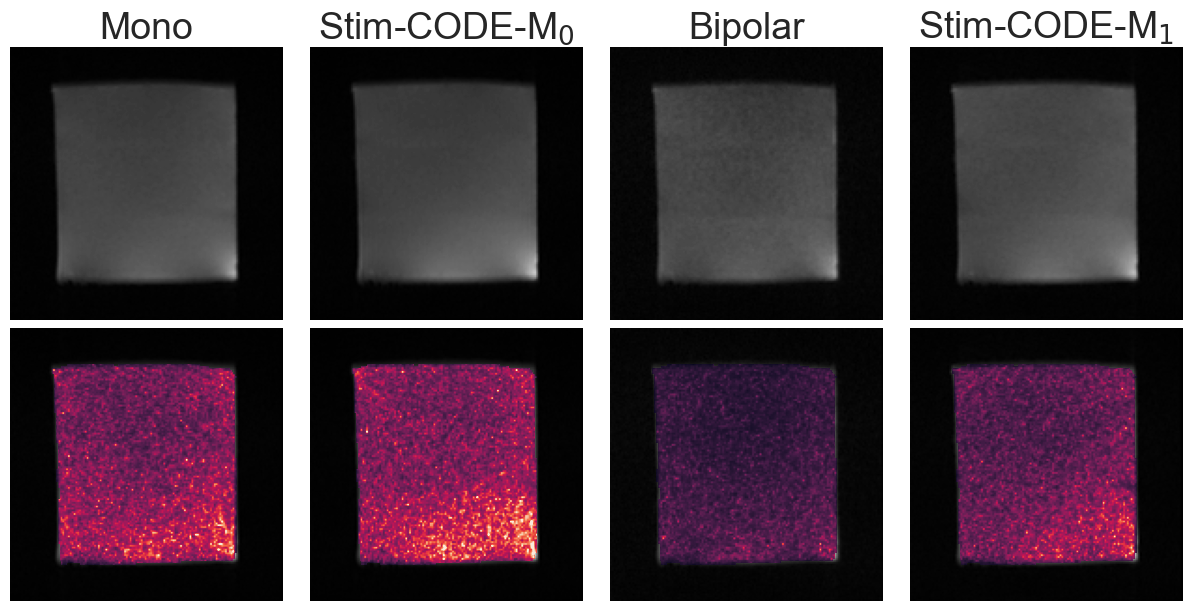


=== Plotting volunteer: Phantom_gel ===


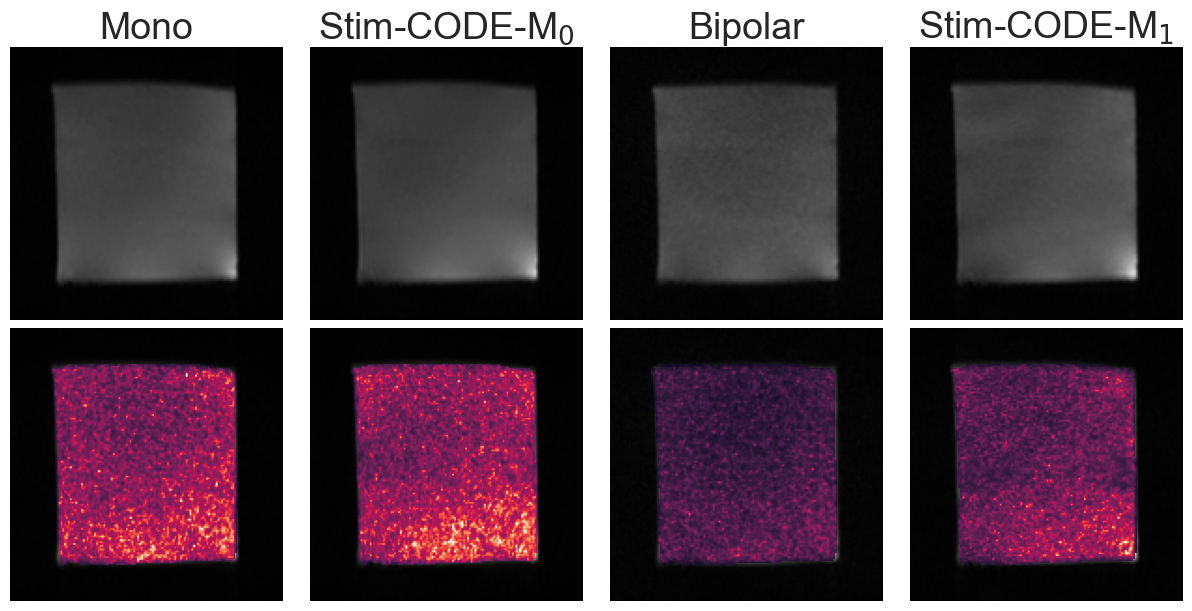


=== Plotting volunteer: Phantom_gel ===


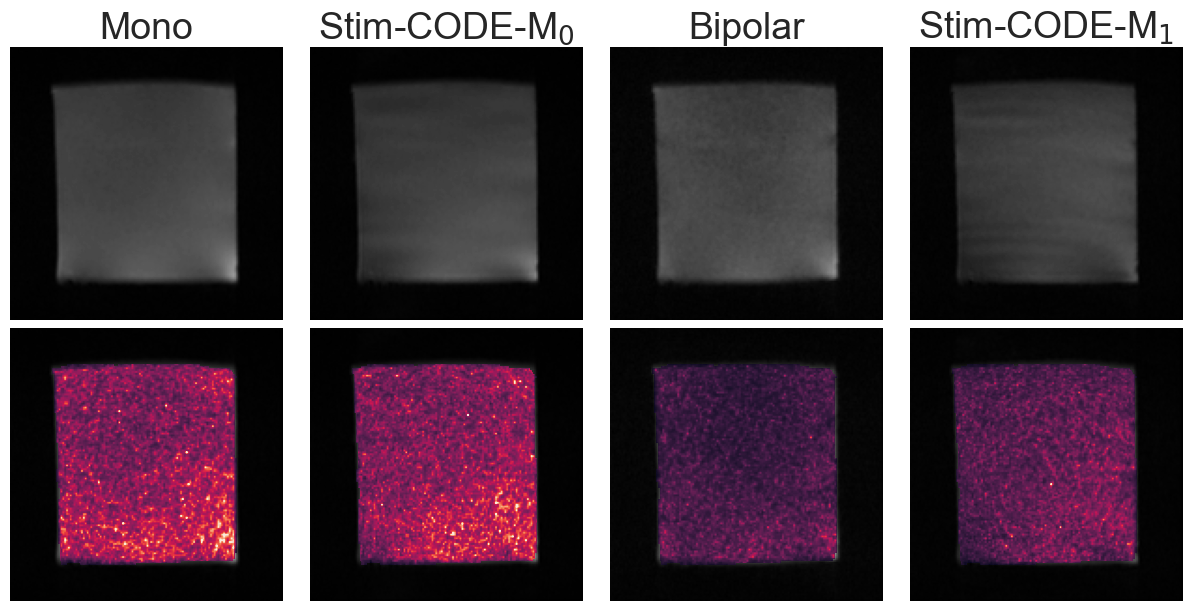


=== Plotting volunteer: Phantom_gel ===


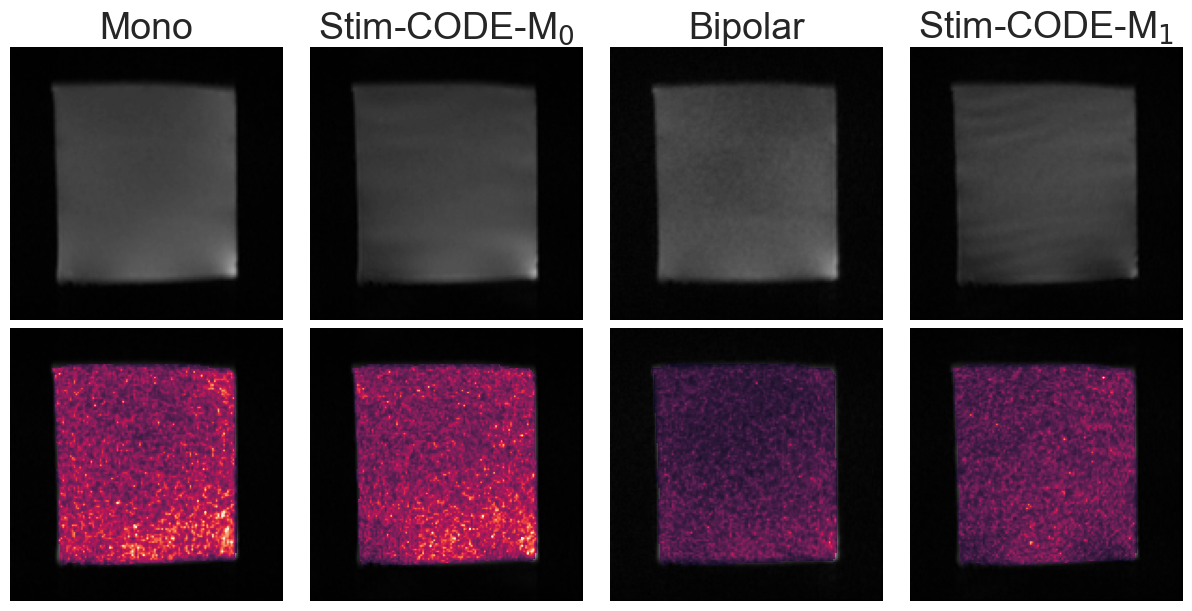

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
mpl.rcParams['axes.labelweight'] = 'normal'
mpl.rcParams['axes.titleweight'] = 'normal'

rocket_cmap = sns.color_palette("rocket", as_cmap=True)

# ------------------------
# Settings
# ------------------------
plot_slices = {
    'V001': 0,
    'V002': 0,
    'V003': 0,
    'V004': 0,
    'V005': 0,
    'V006': 0,
    'V007': 0,
    'V008': 0,
    'V009': 0,
    'V010': 0,
    'Phantom': 0,
    'Phantom_01B': 0,   
    'Phantom_Sphere': 0,
    'Phantom_DWI': 0,
    'Phantom_Head': 0,
    'Phantom_Head_repeat': 0,
    'Phantom_gel':0,
    'Phantom_gel_repeat':0,
}

scans_to_plot = data_folders
for diff_dir in range(4):  # which DWI direction to plot

    # Font sizes
    title_fs = 27
    ylabel_fs = 28
    tick_fs = 18

    # Color scale limits
    dwi_vmin, dwi_vmax = 0, 3000#100
    snr_vmin, snr_vmax = 0, 80


    # ------------------------
    # Loop over volunteers
    # ------------------------
    for volunteer in volunteers:
        print(f"\n=== Plotting volunteer: {volunteer} ===")
        
        slice_idx = plot_slices[volunteer]
        n_rows = 2  # Top: DWI, Bottom: DWI + all SNR masks
        n_cols = len(scans_to_plot)
        
        fig, axs = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 6),constrained_layout=True)
        
        if n_rows == 1:
            axs = np.array(axs).reshape(1, n_cols)
        if n_cols == 1:
            axs = axs[:, np.newaxis]

        # ------------------------
        # Colormap for mask overlays
        # ------------------------
        mask_colors = sns.color_palette("Set2", len(maskbank_all_vols[volunteer]))

        for col_idx, folder in enumerate(scans_to_plot):
            try:
                idx_folder = data_folders.index(folder)
            except ValueError:
                print(f"⚠️ Folder {folder} not found for {volunteer}, skipping")
                continue

            # Raw DWI slice (top row)
            data = data_all_vols[volunteer][idx_folder]
            dwi_img = np.nanmedian(np.real(data), axis=-1)[:, :, slice_idx, diff_dir]
            # If InVivo, multiply top-row DWI by the selected SNR mask
            if mode == 'InVivo':
                # Get the selected mask for this scan (already stored in mask_all_vols)
                selected_mask = mask_all_vols[volunteer][idx_folder][:, :, slice_idx]
                dwi_img = dwi_img * selected_mask
                axs[0, col_idx].imshow(np.zeros(dwi_img.shape), cmap='gray', vmin=dwi_vmin, vmax=dwi_vmax)
                axs[1, col_idx].imshow(np.zeros(dwi_img.shape), cmap='gray', vmin=dwi_vmin, vmax=dwi_vmax)
                
            axs[0, col_idx].imshow(dwi_img, cmap='gray', vmin=dwi_vmin, vmax=dwi_vmax)
            axs[0, col_idx].set_title(col_labels[col_idx], fontsize=title_fs)
            axs[0, col_idx].axis('off')

            # Bottom row: overlay all masks
            axs[1, col_idx].imshow(dwi_img, cmap='gray', vmin=dwi_vmin, vmax=dwi_vmax)

            # Overlay each mask with transparency
            #count =0
            #for m_idx, (mask_name, mask_arr) in enumerate(maskbank_all_vols[volunteer].items()):
            #    mask_slice = mask_arr[:, :, slice_idx].copy()
            #    mask_slice[mask_slice == 0] = np.nan
            #    axs[1, col_idx].imshow(mask_slice*(count + 1), cmap=rocket_cmap,
            #                           alpha=1, vmin=snr_vmin, vmax=snr_vmax)
            #    count += 1

            # Bottom row: overlay all masks on SNR
            snr_img = snr_all_vols[volunteer][idx_folder][:, :, slice_idx, diff_dir]  # SNR for selected DWI dir

            # Show raw DWI as base
            axs[1, col_idx].imshow(dwi_img, cmap='gray', vmin=dwi_vmin, vmax=dwi_vmax)

            # Overlay each mask multiplied by SNR
            for m_idx, (mask_name, mask_arr) in enumerate(maskbank_all_vols[volunteer].items()):
                mask_slice = mask_arr[:, :, slice_idx].copy()
                mask_slice[mask_slice == 0] = np.nan
                snr_masked = snr_img * mask_slice  # multiply SNR by mask
                axs[1, col_idx].imshow(snr_masked, cmap=rocket_cmap,
                                    alpha=1, vmin=snr_vmin, vmax=snr_vmax)

            axs[1, col_idx].axis('off')

            axs[1, col_idx].axis('off')

        # ------------------------
        # Row labels
        # ------------------------
        #fig.text(-0.1, 0.70, 'DWI',      va='center', fontsize=ylabel_fs, fontweight='bold')
        #fig.text(-0.1, 0.30, 'DWI + SNR masks', va='center', fontsize=ylabel_fs, fontweight='bold')

        plt.show()

        fig.savefig(f'fig_snr_{volunteer}_dir{diff_dir}.svg', dpi=300, bbox_inches='tight')

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================
#  GLOBAL FONT + STYLE CONTROL
# ====================================================
TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 30
TICK_FONTSIZE  = 25
SCATTER_SIZE   = 18

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.size": TICK_FONTSIZE,
    "axes.labelsize": LABEL_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
})

# ====================================================
# User choices
# ====================================================

jitter       = 0.12

scan_names = data_folders
mask_names = list(maskbank_all_vols[phantom_name].keys())

palette = sns.color_palette("tab10", len(mask_names))

# ====================================================
# Pre-collect voxel-wise SNR data
# ====================================================
# Stores per scan, per mask, all voxel SNRs for both directions
phantom_snr = {scan: {} for scan in scan_names}

for s, scan in enumerate(scan_names):

    # Load SNR maps for this scan
    snr_map_vol = snr_all_vols[phantom_name][s]  # shape: (X,Y,Z,2) or (..., dirs)
    
    for mask_name in mask_names:
        mask = maskbank_all_vols[phantom_name][mask_name]

        # Direction 0
        snr_dir0 = snr_map_vol[..., 0] * mask
        snr_dir0 = snr_dir0[np.isfinite(snr_dir0) & (snr_dir0 > 0)]
        
        # Direction 1
        snr_dir1 = snr_map_vol[..., 1] * mask
        snr_dir1 = snr_dir1[np.isfinite(snr_dir1) & (snr_dir1 > 0)]

        # Direction 2
        snr_dir2 = snr_map_vol[..., 2] * mask
        snr_dir2 = snr_dir2[np.isfinite(snr_dir2) & (snr_dir2 > 0)]

        # Direction 2
        snr_dir3 = snr_map_vol[..., 3] * mask
        snr_dir3 = snr_dir3[np.isfinite(snr_dir3) & (snr_dir3 > 0)]

        # Store
        phantom_snr[scan][mask_name] = {
            'dir0': snr_dir0,
            'dir1': snr_dir1,
            'dir2': snr_dir2,
            'dir3': snr_dir3,
        }

        print(f"{scan:18s} | {mask_name:15s} | "
              f"SNR Dir0: {snr_dir0.size:7d} | SNR Dir1: {snr_dir1.size:7d}")
        

trap_mmt0_Ncalib2  | mask1           | SNR Dir0:   10347 | SNR Dir1:   10347
gropt_mmt0_Ncalib2 | mask1           | SNR Dir0:   10347 | SNR Dir1:   10347
trap_mmt1_Ncalib2  | mask1           | SNR Dir0:   10347 | SNR Dir1:   10347
gropt_mmt1_Ncalib2 | mask1           | SNR Dir0:   10347 | SNR Dir1:   10347


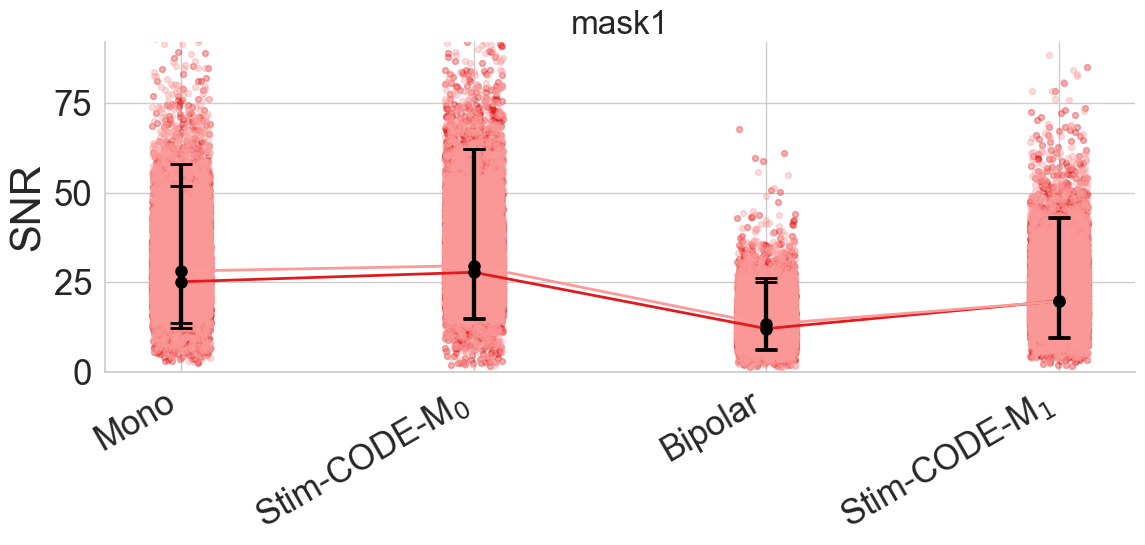

trap_mmt0_Ncalib2  | Dir0 Median SNR:  25.18 (95% CI:  12.25 -  52.05) | Dir1 Median SNR:  28.17 (95% CI:  13.53 -  58.04)
gropt_mmt0_Ncalib2 | Dir0 Median SNR:  27.83 (95% CI:  14.84 -  62.14) | Dir1 Median SNR:  29.69 (95% CI:  15.11 -  62.28)
trap_mmt1_Ncalib2  | Dir0 Median SNR:  12.08 (95% CI:   5.99 -  25.13) | Dir1 Median SNR:  13.27 (95% CI:   6.40 -  26.36)
gropt_mmt1_Ncalib2 | Dir0 Median SNR:  19.84 (95% CI:   9.76 -  42.92) | Dir1 Median SNR:  19.73 (95% CI:   9.40 -  43.36)


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================
# GLOBAL FONT + STYLE CONTROL
# ====================================================
TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 30
TICK_FONTSIZE  = 25
SCATTER_SIZE   = 18
DOT_SIZE       = 8
ERROR_LW       = 3.0
CAPSIZE        = 8
CAPTHICK       = 2
JITTER         = 0.10

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": TICK_FONTSIZE,
    "axes.labelsize": LABEL_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
})

# ====================================================
# USER CHOICES
# ====================================================
mask_to_plot = 'mask1'   # <-- choose single mask here


scan_xtick_labels = [
    'Mono', 'Stim-CODE-M$_0$', 'Bipolar', 'Stim-CODE-M$_1$'
]

DIR0_COLOR = sns.color_palette('Paired', 10)[5]
DIR1_COLOR = sns.color_palette('Paired', 10)[4]

xpos = np.arange(len(scan_names))

# ============================================================
# Bootstrap CI function
# ============================================================
def bootstrap_ci(data):
    data = np.array(data)
    N    = data.shape[0]
    Nbs  = 1000

    np.random.seed(0)
    bs_idx = np.random.randint(0, N, (N, Nbs))
    bs     = data[bs_idx]

    lo = np.percentile(bs, 2.5, axis=0).mean()
    hi = np.percentile(bs, 97.5, axis=0).mean()

    return np.nanmedian(data), lo, hi

# ====================================================
# Plot
# ====================================================
fig, ax = plt.subplots(figsize=(12, 6))

dir0_medians = []
dir1_medians = []

for s, scan in enumerate(scan_names):

    # --------------------------
    # Direction 0
    # --------------------------
    snr_dir0 = phantom_snr[scan][mask_to_plot]['dir0']
    ax.scatter(
        np.full_like(snr_dir0, xpos[s]) +
        np.random.uniform(-JITTER, JITTER, len(snr_dir0)),
        snr_dir0,
        s=SCATTER_SIZE,
        alpha=0.35,
        color=DIR0_COLOR
    )

    med0, lo0, hi0 = bootstrap_ci(snr_dir0)
    dir0_medians.append(med0)

    ax.errorbar(
        xpos[s], med0,
        yerr=[[med0 - lo0], [hi0 - med0]],
        fmt='o', color='black',
        lw=ERROR_LW, markersize=DOT_SIZE,
        capsize=CAPSIZE, capthick=CAPTHICK, zorder=10
    )

    # --------------------------
    # Direction 1
    # --------------------------
    snr_dir1 = phantom_snr[scan][mask_to_plot]['dir1']
    ax.scatter(
        np.full_like(snr_dir1, xpos[s]) +
        np.random.uniform(-JITTER, JITTER, len(snr_dir1)),
        snr_dir1,
        s=SCATTER_SIZE,
        alpha=0.35,
        color=DIR1_COLOR
    )

    med1, lo1, hi1 = bootstrap_ci(snr_dir1)
    dir1_medians.append(med1)

    ax.errorbar(
        xpos[s], med1,
        yerr=[[med1 - lo1], [hi1 - med1]],
        fmt='o', color='black',
        lw=ERROR_LW, markersize=DOT_SIZE,
        capsize=CAPSIZE, capthick=CAPTHICK, zorder=10
    )

# --------------------------
# Connect medians
# --------------------------
ax.plot(xpos, dir0_medians, color=DIR0_COLOR, lw=2)
ax.plot(xpos, dir1_medians, color=DIR1_COLOR, lw=2)

# --------------------------
# Axis formatting
# --------------------------
ax.set_xticks(xpos)
ax.set_xticklabels(scan_xtick_labels, rotation=30, ha='right')
ax.set_ylabel('SNR')
ax.set_title(mask_to_plot)

ax.set_ylim(
    0,
    3.1 * np.nanmax(
        [np.nanmax(dir0_medians), np.nanmax(dir1_medians)]
    )
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

fig.savefig(
    f'Fig_SNR_dir0_dir1_{mask_to_plot}_{phantom_name}.svg',
    dpi=300,
    bbox_inches='tight'
)

# Print median and 95% CI values
for s, scan in enumerate(scan_names):
    snr_dir0 = phantom_snr[scan][mask_to_plot]['dir0']
    med0, lo0, hi0 = bootstrap_ci(snr_dir0)

    snr_dir1 = phantom_snr[scan][mask_to_plot]['dir1']
    med1, lo1, hi1 = bootstrap_ci(snr_dir1)

    print(f"{scan:18s} | "
          f"Dir0 Median SNR: {med0:6.2f} (95% CI: {lo0:6.2f} - {hi0:6.2f}) | "
          f"Dir1 Median SNR: {med1:6.2f} (95% CI: {lo1:6.2f} - {hi1:6.2f})"
    )

In [21]:
(27.83  - 25.18) / 25.18 * 100, (19.84  - 12.08) / 12.08 * 100, 

(10.524225575853846, 64.23841059602648)

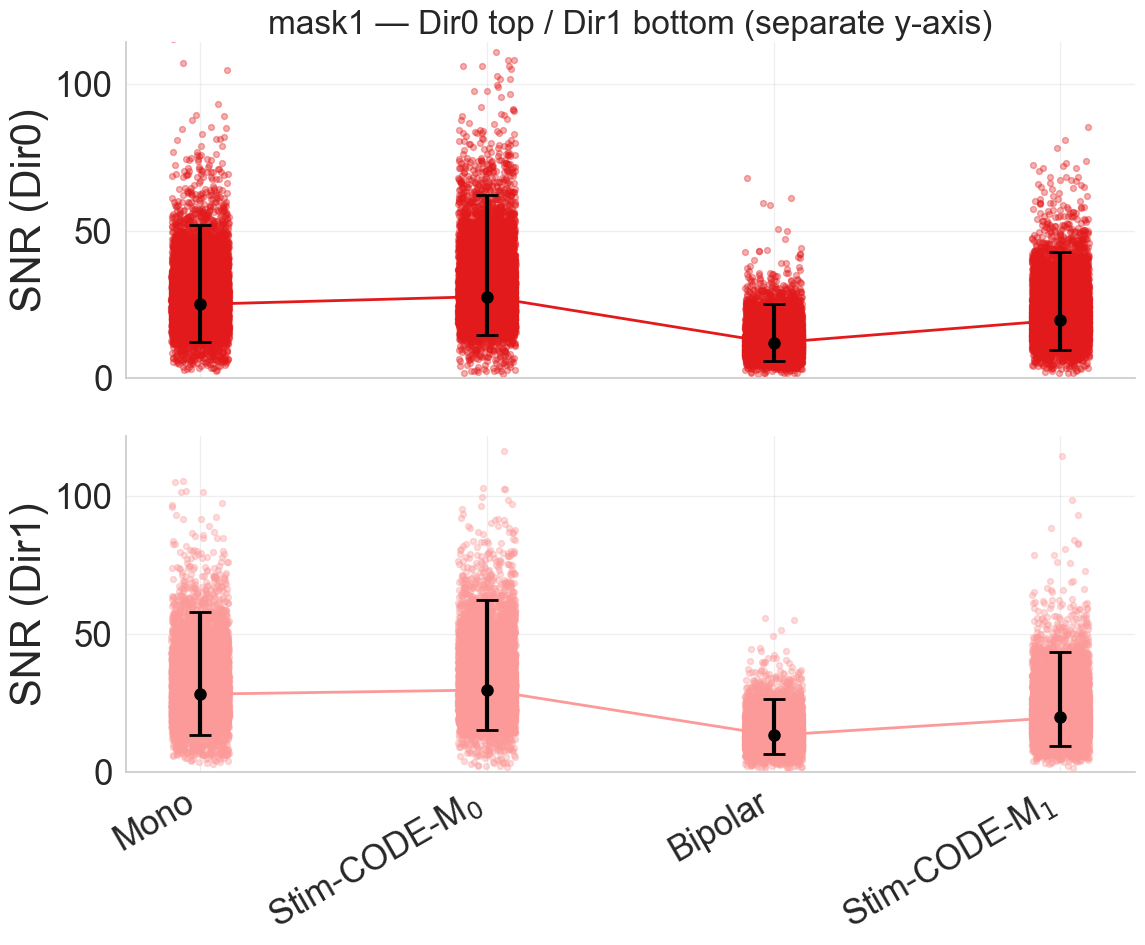

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
ax0, ax1 = axes

dir0_medians = []
dir1_medians = []

for s, scan in enumerate(scan_names):

    # --------------------------
    # Direction 0 (top)
    # --------------------------
    snr_dir0 = phantom_snr[scan][mask_to_plot]['dir0']
    ax0.scatter(
        np.full_like(snr_dir0, xpos[s]) + np.random.uniform(-JITTER, JITTER, len(snr_dir0)),
        snr_dir0,
        s=SCATTER_SIZE, alpha=0.35, color=DIR0_COLOR
    )
    med0, lo0, hi0 = bootstrap_ci(snr_dir0)
    dir0_medians.append(med0)
    ax0.errorbar(
        xpos[s], med0, yerr=[[med0 - lo0],[hi0 - med0]],
        fmt='o', color='black', lw=ERROR_LW, markersize=DOT_SIZE,
        capsize=CAPSIZE, capthick=CAPTHICK, zorder=10
    )

    # --------------------------
    # Direction 1 (bottom)
    # --------------------------
    snr_dir1 = phantom_snr[scan][mask_to_plot]['dir1']
    ax1.scatter(
        np.full_like(snr_dir1, xpos[s]) + np.random.uniform(-JITTER, JITTER, len(snr_dir1)),
        snr_dir1,
        s=SCATTER_SIZE, alpha=0.35, color=DIR1_COLOR
    )
    med1, lo1, hi1 = bootstrap_ci(snr_dir1)
    dir1_medians.append(med1)
    ax1.errorbar(
        xpos[s], med1, yerr=[[med1 - lo1],[hi1 - med1]],
        fmt='o', color='black', lw=ERROR_LW, markersize=DOT_SIZE,
        capsize=CAPSIZE, capthick=CAPTHICK, zorder=10
    )

# Connect medians
ax0.plot(xpos, dir0_medians, color=DIR0_COLOR, lw=2)
ax1.plot(xpos, dir1_medians, color=DIR1_COLOR, lw=2)

# Axis formatting
ax0.set_ylabel('SNR (Dir0)')
ax1.set_ylabel('SNR (Dir1)')
ax1.set_xticks(xpos)
ax1.set_xticklabels(scan_xtick_labels, rotation=30, ha='right')

# Set separate y-limits
ax0.set_ylim(0, 4.1 * np.nanmax(dir0_medians))
ax1.set_ylim(0, 4.1 * np.nanmax(dir1_medians))

# Common styling
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.3)

ax0.set_title(f'{mask_to_plot} — Dir0 top / Dir1 bottom (separate y-axis)')

plt.tight_layout()
plt.show()

fig.savefig(f'Fig_SNR_dir0_dir1_separateY_{mask_to_plot}_{phantom_name}.svg', dpi=300, bbox_inches='tight')

trap_mmt0_Ncalib2  | dir0 Median:  25.18 (95% CI:  12.25 -  52.05)
trap_mmt0_Ncalib2  | dir1 Median:  28.17 (95% CI:  13.53 -  58.04)
trap_mmt0_Ncalib2  | dir2 Median:  27.98 (95% CI:  12.92 -  56.39)
trap_mmt0_Ncalib2  | dir3 Median:  28.09 (95% CI:  12.46 -  56.74)
gropt_mmt0_Ncalib2 | dir0 Median:  27.83 (95% CI:  14.84 -  62.14)
gropt_mmt0_Ncalib2 | dir1 Median:  29.69 (95% CI:  15.11 -  62.28)
gropt_mmt0_Ncalib2 | dir2 Median:  27.32 (95% CI:  13.61 -  53.59)
gropt_mmt0_Ncalib2 | dir3 Median:  26.93 (95% CI:  13.14 -  52.97)
trap_mmt1_Ncalib2  | dir0 Median:  12.08 (95% CI:   5.99 -  25.13)
trap_mmt1_Ncalib2  | dir1 Median:  13.27 (95% CI:   6.40 -  26.36)
trap_mmt1_Ncalib2  | dir2 Median:  13.25 (95% CI:   6.69 -  26.59)
trap_mmt1_Ncalib2  | dir3 Median:  13.25 (95% CI:   6.39 -  27.29)
gropt_mmt1_Ncalib2 | dir0 Median:  19.84 (95% CI:   9.76 -  42.92)
gropt_mmt1_Ncalib2 | dir1 Median:  19.73 (95% CI:   9.40 -  43.36)
gropt_mmt1_Ncalib2 | dir2 Median:  18.22 (95% CI:   8.65 -  34

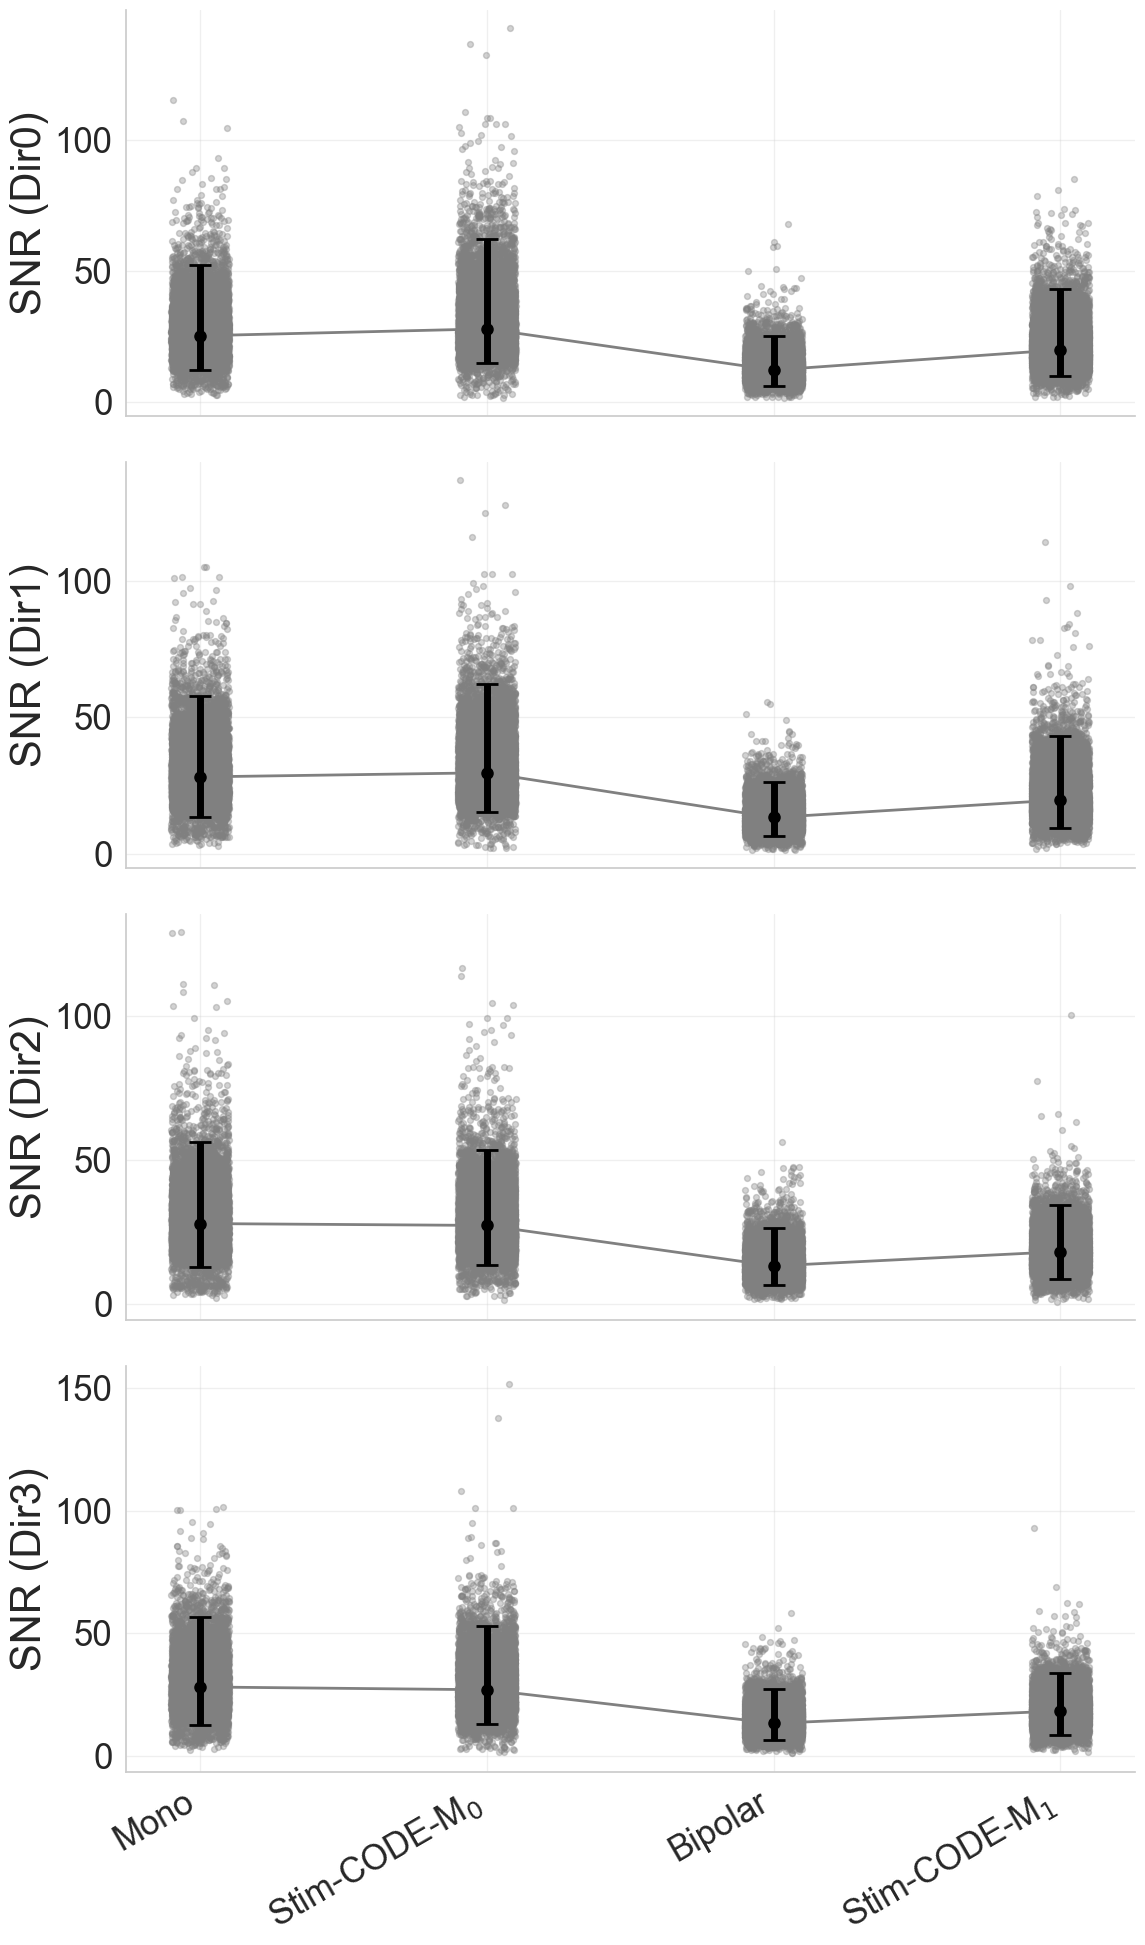

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================
# GLOBAL FONT + STYLE CONTROL
# ====================================================
TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 30
TICK_FONTSIZE  = 25
SCATTER_SIZE   = 18
DOT_SIZE       = 8
ERROR_LW       = 5.0
CAPSIZE        = 8
CAPTHICK       = 2
JITTER         = 0.10

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": TICK_FONTSIZE,
    "axes.labelsize": LABEL_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
})

# ====================================================
# USER CHOICES
# ====================================================
mask_to_plot = 'mask1'   # <-- choose single mask here
scan_xtick_labels = ['Mono', 'Stim-CODE-M$_0$', 'Bipolar', 'Stim-CODE-M$_1$']

# Diffusion directions colors (4 directions)
DIR_COLORS = sns.color_palette('Paired', 10)[4:8]  # 4 distinct colors
N_DIRS = 4

xpos = np.arange(len(scan_names))

# ============================================================
# Bootstrap CI function
# ============================================================
def bootstrap_ci(data):
    data = np.array(data)
    N    = data.shape[0]
    Nbs  = 1000

    np.random.seed(0)
    bs_idx = np.random.randint(0, N, (N, Nbs))
    bs     = data[bs_idx]

    lo = np.percentile(bs, 2.5, axis=0).mean()
    hi = np.percentile(bs, 97.5, axis=0).mean()

    return np.nanmedian(data), lo, hi

# ====================================================
# Collect median + CI for all directions
# ====================================================
all_medians = {dir_idx: [] for dir_idx in range(N_DIRS)}
all_lo_hi   = {dir_idx: [] for dir_idx in range(N_DIRS)}

for s, scan in enumerate(scan_names):
    for dir_idx in range(N_DIRS):
        key = f'dir{dir_idx}'
        snr_dir = phantom_snr[scan][mask_to_plot][key]
        med, lo, hi = bootstrap_ci(snr_dir)
        all_medians[dir_idx].append(med)
        all_lo_hi[dir_idx].append((lo, hi))

        # Print values
        print(f"{scan:18s} | {key} Median: {med:6.2f} (95% CI: {lo:6.2f} - {hi:6.2f})")

# ====================================================
# Plot each direction in separate subplot
# ====================================================
fig, axes = plt.subplots(N_DIRS, 1, figsize=(12, 20), dpi = 100, sharex=True)
if N_DIRS == 1:
    axes = [axes]

for dir_idx in range(N_DIRS):
    ax = axes[dir_idx]
    color = DIR_COLORS[dir_idx]

    for s, scan in enumerate(scan_names):
        snr_dir = phantom_snr[scan][mask_to_plot][f'dir{dir_idx}']
        # Scatter points
        ax.scatter(
            np.full_like(snr_dir, xpos[s]) +
            np.random.uniform(-JITTER, JITTER, len(snr_dir)),
            snr_dir,
            s=SCATTER_SIZE,
            alpha=0.35,
            color='gray',
        )
        # Error bars
        med = all_medians[dir_idx][s]
        lo, hi = all_lo_hi[dir_idx][s]
        ax.errorbar(
            xpos[s], med,
            yerr=[[med - lo], [hi - med]],
            fmt='o', color='black',
            lw=ERROR_LW, markersize=DOT_SIZE,
            capsize=CAPSIZE, capthick=CAPTHICK, zorder=10
        )

    # Connect medians
    ax.plot(xpos, all_medians[dir_idx], color='gray', lw=2)

    ax.set_ylabel(f'SNR (Dir{dir_idx})')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.3)

axes[-1].set_xticks(xpos)
axes[-1].set_xticklabels(scan_xtick_labels, rotation=30, ha='right')
plt.tight_layout()
plt.show()

# ====================================================
# Save figure
# ====================================================
fig.savefig(
    f'Fig_SNR_4dirs_separateY_{mask_to_plot}_{phantom_name}.svg',
    dpi=50,
    bbox_inches='tight'
)

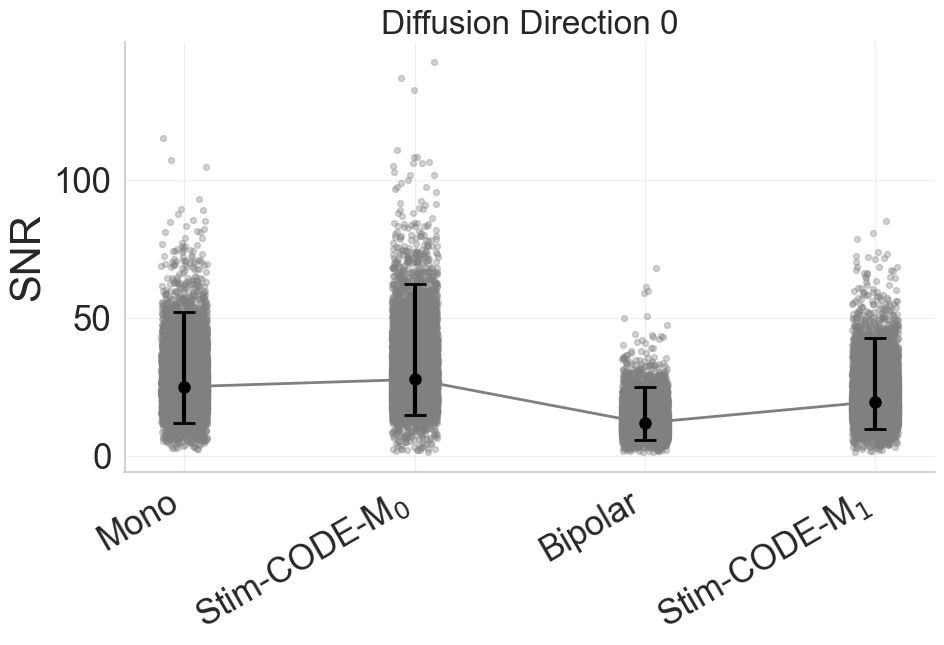

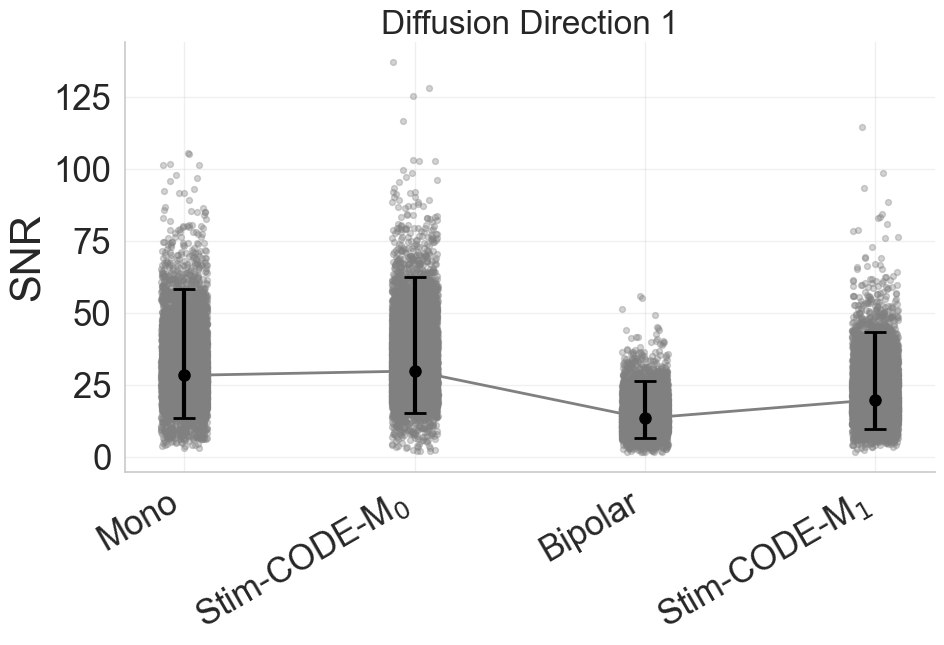

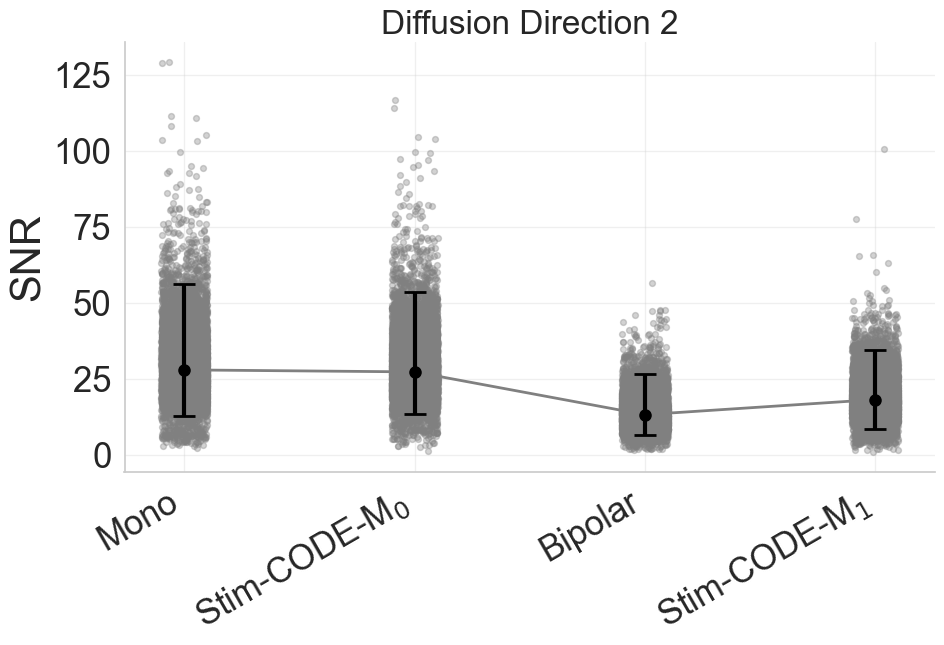

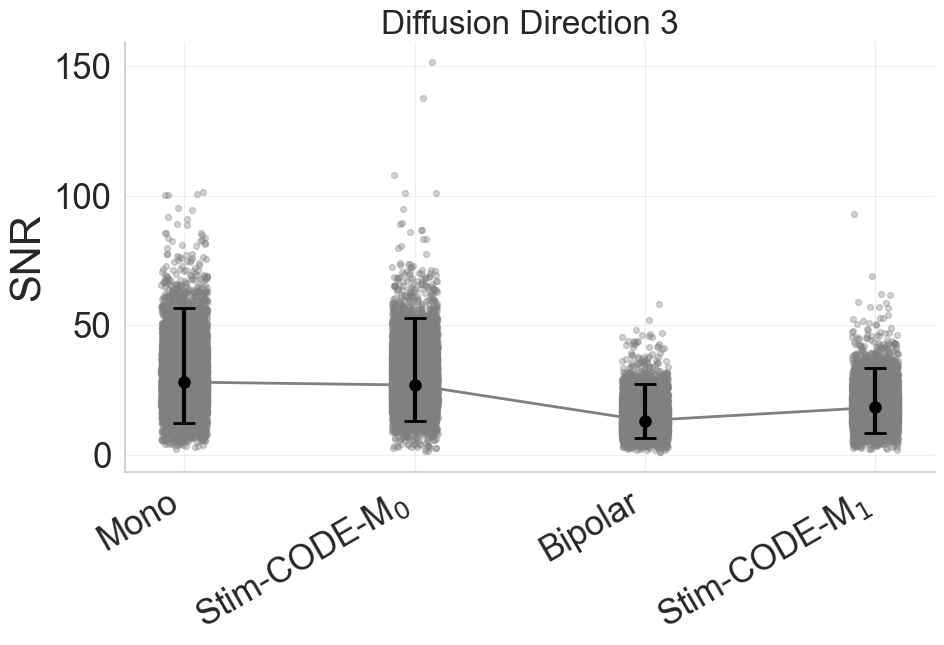

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================
# GLOBAL FONT + STYLE CONTROL
# ====================================================
TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 30
TICK_FONTSIZE  = 25
SCATTER_SIZE   = 18
DOT_SIZE       = 8
ERROR_LW       = 3.0
CAPSIZE        = 8
CAPTHICK       = 2
JITTER         = 0.10

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": TICK_FONTSIZE,
    "axes.labelsize": LABEL_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
})

# ====================================================
# USER CHOICES
# ====================================================
mask_to_plot = 'mask1'
scan_xtick_labels = ['Mono', 'Stim-CODE-M$_0$', 'Bipolar', 'Stim-CODE-M$_1$']

DIR_COLORS = sns.color_palette('Paired', 10)[4:8]
N_DIRS = 4
xpos = np.arange(len(scan_names))

# ====================================================
# Bootstrap CI
# ====================================================
def bootstrap_ci(data):
    data = np.array(data)
    N    = data.shape[0]
    Nbs  = 1000

    np.random.seed(0)
    bs_idx = np.random.randint(0, N, (N, Nbs))
    bs     = data[bs_idx]

    lo = np.percentile(bs, 2.5, axis=0).mean()
    hi = np.percentile(bs, 97.5, axis=0).mean()

    return np.nanmedian(data), lo, hi

# ====================================================
# Collect median + CI
# ====================================================
all_medians = {d: [] for d in range(N_DIRS)}
all_lo_hi   = {d: [] for d in range(N_DIRS)}

for s, scan in enumerate(scan_names):
    for d in range(N_DIRS):
        snr_dir = phantom_snr[scan][mask_to_plot][f'dir{d}']
        med, lo, hi = bootstrap_ci(snr_dir)
        all_medians[d].append(med)
        all_lo_hi[d].append((lo, hi))

        #print(f"{scan:18s} | dir{d} Median: {med:6.2f} "
        #      f"(95% CI: {lo:6.2f} – {hi:6.2f})")

# ====================================================
# One figure per direction
# ====================================================
for d in range(N_DIRS):

    fig, ax = plt.subplots(figsize=(10, 7), dpi=100)
    color = DIR_COLORS[d]

    for s, scan in enumerate(scan_names):
        snr_dir = phantom_snr[scan][mask_to_plot][f'dir{d}']

        # Scatter
        ax.scatter(
            np.full_like(snr_dir, xpos[s]) +
            np.random.uniform(-JITTER, JITTER, len(snr_dir)),
            snr_dir,
            s=SCATTER_SIZE,
            alpha=0.35,
            color='gray'
        )

        # Error bar
        med = all_medians[d][s]
        lo, hi = all_lo_hi[d][s]

        ax.errorbar(
            xpos[s], med,
            yerr=[[med - lo], [hi - med]],
            fmt='o',
            color='black',
            lw=ERROR_LW,
            markersize=DOT_SIZE,
            capsize=CAPSIZE,
            capthick=CAPTHICK,
            zorder=10
        )

    # Connect medians
    ax.plot(xpos, all_medians[d], color='gray', lw=2)

    ax.set_xticks(xpos)
    ax.set_xticklabels(scan_xtick_labels, rotation=30, ha='right')
    ax.set_ylabel('SNR')
    ax.set_title(f'Diffusion Direction {d}')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Save each direction separately
    fig.savefig(
        f'Fig_SNR_Dir{d}_{mask_to_plot}_{phantom_name}.svg',
        bbox_inches='tight'
    )